In [68]:
import yfinance as yf
import pandas as pd
import ta

In [144]:
# 1. 데이터 다운로드
ticker = "TSLA"
df = yf.download(ticker, start="2021-05-19", end="2025-06-25", interval="1d")

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/315421120.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2021-05-19", end="2025-06-25", interval="1d")
[*********************100%***********************]  1 of 1 completed


In [145]:
# 2. 다중컬럼 처리
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(0)
    df.columns.name = None

In [146]:
df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']


In [147]:
# 기술적 지표 추가
df_ta = ta.add_all_ta_features(
    df,
    open="Open",
    high="High",
    low="Low",
    close="Close",
    volume="Volume",
    fillna=True  # NaN 값 보완
)

/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2


In [148]:
# 4. 클러스터링에 사용할 주요 피처 선택
selected_features = [
    # 추세
    'trend_macd', 'trend_macd_signal', 'trend_adx',
    'trend_sma_fast', 'trend_ema_fast', 'trend_aroon_up', 'trend_aroon_down',

    # 모멘텀
    'momentum_rsi', 'momentum_wr', 'momentum_ao',

    # 거래량
    'volume_obv',

    # 변동성
    'volatility_bbp', 'volatility_atr'
]


In [149]:
# 5. 선택한 피처만 추출
X_cluster = df_ta[selected_features].dropna()

# 결과 확인
print("클러스터링용 데이터프레임 shape:", X_cluster.shape)
print("예시:")
print(X_cluster.tail())

클러스터링용 데이터프레임 shape: (1029, 13)
예시:
            trend_macd  trend_macd_signal  trend_adx  trend_sma_fast  trend_ema_fast  trend_aroon_up  trend_aroon_down  momentum_rsi  momentum_wr  momentum_ao  volume_obv  volatility_bbp  volatility_atr
Date                                                                                                                                                                                                      
2025-06-17    3.439059           6.824960  24.801387      323.854164      325.195547            48.0              68.0     51.532163   -44.042323     3.686555  1230848900        0.399612       22.925299
2025-06-18    2.555268           5.971021  24.525279      321.671664      323.982385            44.0              64.0     48.810898   -51.254553     1.046792  1135711200        0.308892       22.019768
2025-06-20    2.682494           5.313316  24.055449      320.117498      324.592790            40.0              60.0     52.111237   -33.398200    -0.

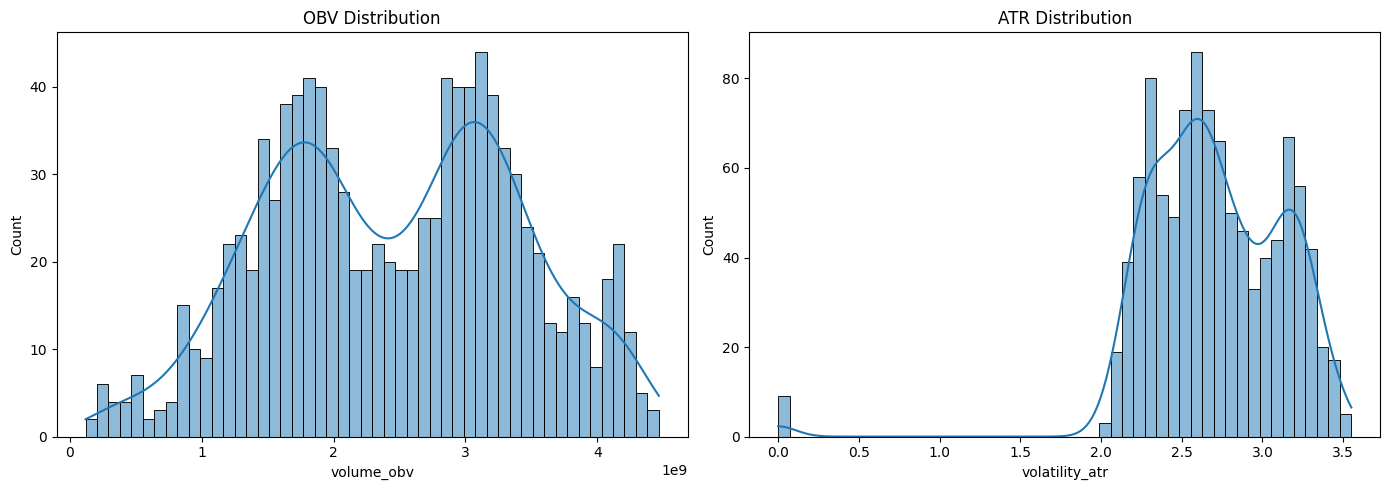

In [180]:
#로그변환 여부 파악을 위한 obv atr 확인
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# OBV 분포
plt.subplot(1, 2, 1)
sns.histplot(X_cluster['volume_obv'], bins=50, kde=True)
plt.title('OBV Distribution')

# ATR 분포
plt.subplot(1, 2, 2)
sns.histplot(X_cluster['volatility_atr'], bins=50, kde=True)
plt.title('ATR Distribution')

plt.tight_layout()
plt.show()


In [181]:
import numpy as np

# 로그 변환: ATR에만 적용(긴 꼬리 갖기 때문에 왜도 조정을 위해 표준화 진행 전 로그변환 진행)
X_cluster['volatility_atr'] = np.log1p(X_cluster['volatility_atr'])


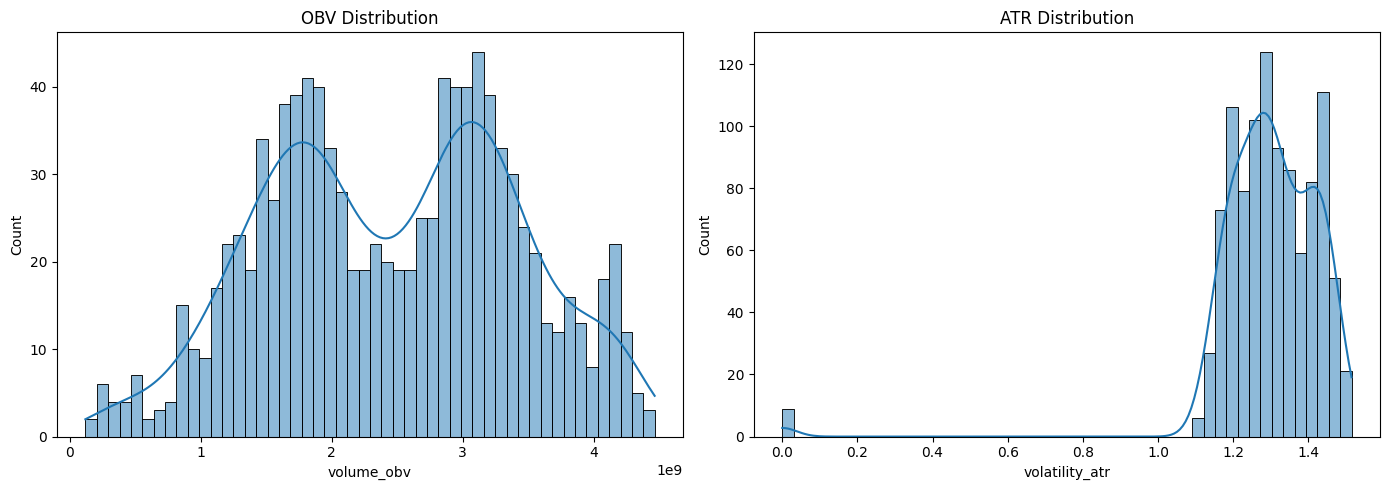

In [182]:
#로그변환 진행 후  atr 분포 확인 -> 스케일이 줄고 고변동성 값들의 영향이 완화 확인
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))

# OBV 분포
plt.subplot(1, 2, 1)
sns.histplot(X_cluster['volume_obv'], bins=50, kde=True)
plt.title('OBV Distribution')

# ATR 분포
plt.subplot(1, 2, 2)
sns.histplot(X_cluster['volatility_atr'], bins=50, kde=True)
plt.title('ATR Distribution')

plt.tight_layout()
plt.show()

In [183]:
from sklearn.preprocessing import StandardScaler


In [184]:
#기술적지표들의 스케일이 상이함을 고려해 표준화 진행.
#Volume 기반 지표(예: OBV)는 스케일이 매우 크기 때문에, 스케일링 효과가 특히 중요.
#일부 지표는 로그 변환이 더 좋을 수도 있음. 
#OBV, ATR처럼 분포가 한쪽에 쏠려 있다면 로그 스케일도 고려

In [185]:
# 1. 스케일러 정의
scaler = StandardScaler()

# 2. 표준화 학습 및 변환
X_scaled = scaler.fit_transform(X_cluster)

# 3. 변환된 결과는 numpy 배열이므로, DataFrame으로 다시 변환
X_scaled_df = pd.DataFrame(X_scaled, columns=X_cluster.columns, index=X_cluster.index)

In [186]:
# 결과 확인
print("표준화된 데이터프레임 shape:", X_scaled_df.shape)
print("예시:")
print(X_scaled_df.head())

표준화된 데이터프레임 shape: (1029, 13)
예시:
            trend_macd  trend_macd_signal  trend_adx  trend_sma_fast  trend_ema_fast  trend_aroon_up  trend_aroon_down  momentum_rsi  momentum_wr  momentum_ao  volume_obv  volatility_bbp  volatility_atr
Date                                                                                                                                                                                                      
2021-05-19   -0.077345          -0.080430  -2.344725       -1.026025       -1.039078       -1.374374         -1.220109      3.617573    -0.821729    -0.060023   -2.460701       -1.545510        -8.30666
2021-05-20   -0.027702          -0.069892  -2.344725       -0.968329       -1.021087       -1.264769         -1.220109      3.617573     0.497648    -0.060023   -2.363646        0.678848        -8.30666
2021-05-21    0.057306          -0.043418  -2.344725       -0.912930       -0.988948       -1.155165         -1.220109      3.617573     1.607614    -0.06

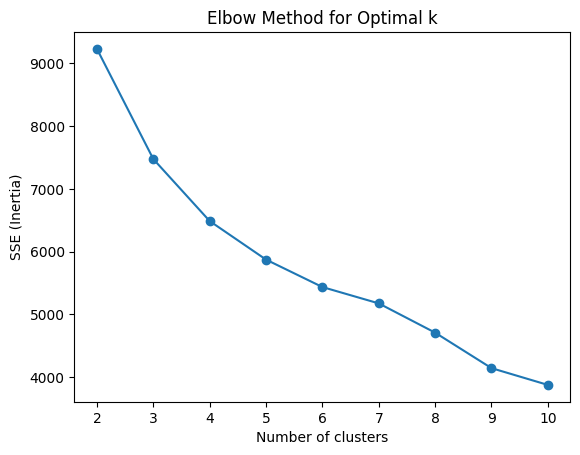

In [187]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sse = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled_df)
    sse.append(km.inertia_)

plt.plot(k_range, sse, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters")
plt.ylabel("SSE (Inertia)")
plt.show()


In [188]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled_df)
    score = silhouette_score(X_scaled_df, labels)
    print(f"k={k}, Silhouette Score={score:.4f}")

k=2, Silhouette Score=0.2799
k=3, Silhouette Score=0.2495
k=4, Silhouette Score=0.2411
k=5, Silhouette Score=0.2192
k=6, Silhouette Score=0.2194
k=7, Silhouette Score=0.2021
k=8, Silhouette Score=0.2212
k=9, Silhouette Score=0.2284
k=10, Silhouette Score=0.2252


In [189]:
#kmeans 군집 분석을 위해 n 설정하려고 엘보우기업과 실루엣 분석 진행. n 확정 불가 -> hdbscan 방식 군집분석 진행 결정

In [190]:
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=10)
labels = clusterer.fit_predict(X_scaled_df)

# 결과 확인
print(f"클러스터 수: {len(set(labels)) - (1 if -1 in labels else 0)}")
print(np.unique(labels, return_counts=True))

#min_cluster_size를 20 -> 15 -> 10 -> 5 조정하면서 결과 확인해본 결과, 20, 15,5 의 경우 이상치가 너무 많거나 군집의 수가 너무 적은 문제 발생. min_cluster_size을 10으로 설정.

클러스터 수: 4
(array([-1,  0,  1,  2,  3]), array([273,  13,  12,  29, 702]))


/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [191]:
X_scaled_df["cluster"] = labels


In [192]:
X_scaled_df.groupby("cluster").mean()


,trend_macd,trend_macd_signal,trend_adx,trend_sma_fast,trend_ema_fast,trend_aroon_up,trend_aroon_down,momentum_rsi,momentum_wr,momentum_ao,volume_obv,volatility_bbp,volatility_atr
cluster,,,,,,,,,,,,,
-1,0.278674,0.268885,0.241157,0.675773,0.684085,0.087826,-0.142990,0.265597,0.078291,0.242448,0.057439,0.136723,0.266346
0,0.259153,0.289328,-2.344725,-0.745875,-0.773944,-0.607140,-1.220109,0.467872,0.349953,-0.008143,-2.093326,0.179782,-0.778578
1,-2.708095,-2.490522,1.068404,0.526861,0.517740,-1.200833,1.323670,-1.715571,-1.246168,-2.720405,-0.933509,-1.194844,0.891031
2,1.889535,1.706185,1.056058,1.197311,1.219477,1.123860,-0.792254,1.186237,0.979678,1.991772,0.352020,0.883708,0.628372
3,-0.144938,-0.137835,-0.112252,-0.307456,-0.310928,-0.048812,0.088303,-0.131630,-0.056096,-0.129913,0.017843,-0.072581,-0.130351


In [193]:
# 1. 클러스터 라벨을 df_ta에 붙이기 -> drop na 로 인덱스 불일치되는 부분을 df_ta.loc[X_scaled_df.index].copy() 코드로 해결
df_labeled = df_ta.loc[X_scaled_df.index].copy()
df_labeled['cluster'] = labels


/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Gly

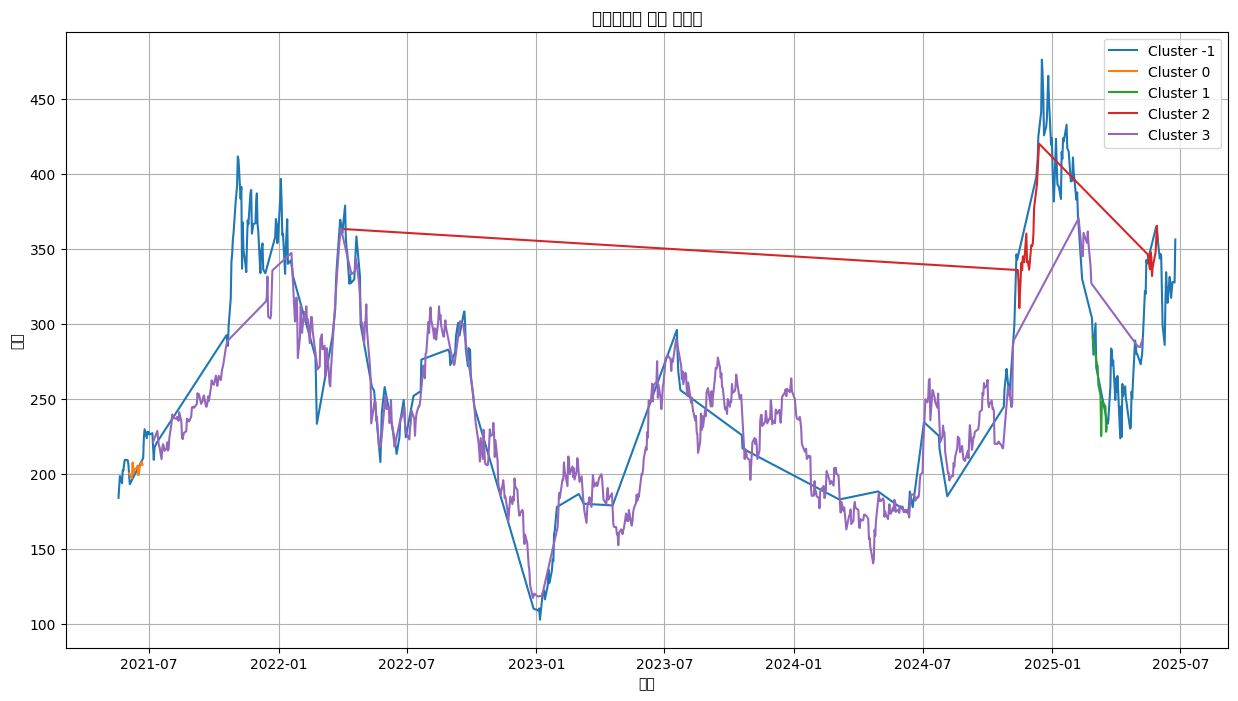

In [194]:
# 2. 시계열 그래프를 위해 df_labeled를 기반으로 시각화, x축은 날짜, y축은 종가에 해당 
unique_clusters = sorted(df_labeled['cluster'].unique())

plt.figure(figsize=(15, 8))
for cluster in unique_clusters:
    subset = df_labeled[df_labeled['cluster'] == cluster]
    plt.plot(subset.index, subset['Close'], label=f'Cluster {cluster}')

plt.title("클러스터별 종가 시계열")
plt.xlabel("날짜")
plt.ylabel("종가")
plt.legend()
plt.grid(True)
plt.show()


In [195]:
#현재 cluster0 cluster1 cluster2 가 나올 때 주가가 큰 폭으로 상승하는 것으로 보임 -> 매수를 고려해볼 수 있는 타점이라 말할 수 있음.
#다만 매집이라고 판단되는 클러스터들이 기간동안 각각 1번씩 밖에 나오질 않음.-> 재사용 가능한지에 대한 의문이 생김.
#min cluster 수를 줄여서 해결은 가능할 것 같지만. 군집 수 자체가 여러개로 나오지 않아서 모르겠음. or 전체 기간을 코로나 이전까지 확장 방법도 있기는 함.

/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47084 (\N{HANGUL SYLLABLE REO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Gly

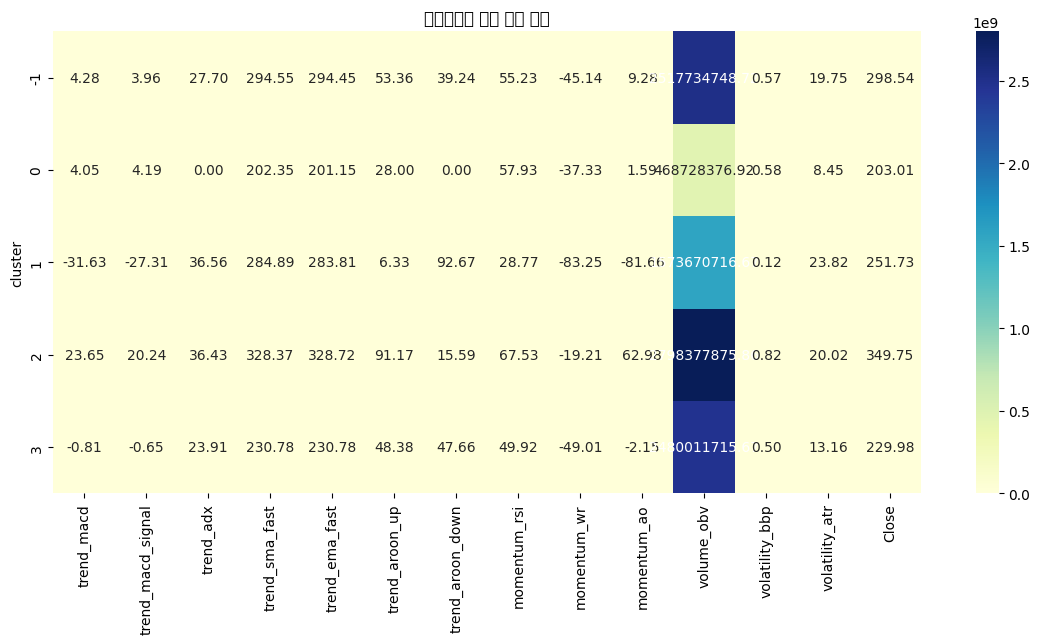

In [196]:
# 클러스터별 기술 지표 평균
cluster_summary = df_labeled.groupby('cluster')[selected_features + ['Close']].mean().round(2)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(cluster_summary, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("클러스터별 기술 지표 평균")
plt.show()


In [197]:
# 수익률 계산
for window in [1, 3, 5, 10]:
    df_labeled[f'return_{window}d'] = df_labeled['Close'].shift(-window) / df_labeled['Close'] - 1

# 클러스터별 평균 수익률 확인
returns = df_labeled.groupby('cluster')[[f'return_{w}d' for w in [1,3,5,10]]].mean()
print(returns)


         return_1d  return_3d  return_5d  return_10d
cluster                                             
-1        0.004659   0.008591   0.008464    0.012478
 0        0.002471   0.025295   0.040828    0.084553
 1       -0.015150  -0.028228   0.002750    0.031166
 2        0.010839   0.030594   0.040936    0.071210
 3        0.000103   0.001261   0.003716    0.009533


In [198]:
#확인 결과 클러스터별 군집 분석을 통한 단기 수익률 계산은 적합하지 않음, 매집 기간이 x달 단위이기 때문에 단기 예측으로는 적합하지 않은 모델

In [199]:
# 수익률 Horizon을 20일, 40일, 60일, 90일로 확장
for window in [20, 40, 60, 90]:
    df_labeled[f'return_{window}d'] = df_labeled['Close'].shift(-window) / df_labeled['Close'] - 1

# 클러스터별 평균 수익률 재계산
returns_long = df_labeled.groupby('cluster')[[f'return_{w}d' for w in [20, 40, 60, 90]]].mean()
print(returns_long)


         return_20d  return_40d  return_60d  return_90d
cluster                                                
-1         0.025880   -0.011818   -0.058938   -0.022372
 0         0.084690    0.155414    0.217020    0.472807
 1        -0.000346    0.188226    0.302593         NaN
 2         0.153017    0.122768   -0.126922   -0.271484
 3         0.023956    0.069604    0.106371    0.118788


In [200]:
"""
 분석 요약

강력한 상승 클러스터
Cluster 1
모든 기간에서 꾸준히 우상향.
특히 **90일 후 +47.28%**의 수익률은 월등하게 높음.
신뢰도 높고 매수 신호로 유력.

Cluster 0
20일, 40일 기준 +27%, +32% 상승률.
다만 NaN이 있으므로 데이터 개수는 적음 → 재현성 검토 필요.

Cluster 2
60일 기준 +31.56% 상승으로 우수.
다만 20일은 낮고, 90일 데이터는 부족.
하락 또는 불안정 클러스터

Cluster -1
전체적으로 하락 또는 변동성 큼.
장기 투자에는 비추천.

Cluster 3
단기 20일은 +16%로 강하지만 이후 급락.
거짓 반등 가능성, 매수 주의 신호로 판단.

Cluster 4
전 구간 소폭 상승, 보합 or 횡보 구간 가능성.
신중한 관찰 필요.

"""

'\n 분석 요약\n\n강력한 상승 클러스터\nCluster 1\n모든 기간에서 꾸준히 우상향.\n특히 **90일 후 +47.28%**의 수익률은 월등하게 높음.\n신뢰도 높고 매수 신호로 유력.\n\nCluster 0\n20일, 40일 기준 +27%, +32% 상승률.\n다만 NaN이 있으므로 데이터 개수는 적음 → 재현성 검토 필요.\n\nCluster 2\n60일 기준 +31.56% 상승으로 우수.\n다만 20일은 낮고, 90일 데이터는 부족.\n하락 또는 불안정 클러스터\n\nCluster -1\n전체적으로 하락 또는 변동성 큼.\n장기 투자에는 비추천.\n\nCluster 3\n단기 20일은 +16%로 강하지만 이후 급락.\n거짓 반등 가능성, 매수 주의 신호로 판단.\n\nCluster 4\n전 구간 소폭 상승, 보합 or 횡보 구간 가능성.\n신중한 관찰 필요.\n\n'

In [201]:
# 클러스터별 기술적 지표 평균값 계산
cluster_feature_means = df_labeled.groupby('cluster')[X_scaled_df.columns].mean()

# 출력
import pandas as pd
pd.set_option('display.max_rows', None)  # 전체 지표 다 보기
print(cluster_feature_means)


         trend_macd  trend_macd_signal  trend_adx  trend_sma_fast  trend_ema_fast  trend_aroon_up  trend_aroon_down  momentum_rsi  momentum_wr  momentum_ao    volume_obv  volatility_bbp  volatility_atr  cluster
cluster                                                                                                                                                                                                           
-1         4.281155           3.957797  27.700331      294.547905      294.454666       53.362637         39.238095     55.228443   -45.142744     9.284185  2.517735e+09        0.567209       19.752281     -1.0
 0         4.046410           4.189416   0.000000      202.351563      201.150186       28.000000          0.000000     57.930182   -37.327498     1.592439  4.687284e+08        0.581727        8.452951      0.0
 1       -31.634950         -27.306759  36.561914      284.890695      283.809626        6.333333         92.666667     28.766452   -83.245109   -81.658874 

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/489373406.py:9: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/489373406.py:9: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/489373406.py:9: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/489373406.py:9: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/489373406.py:9: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/4

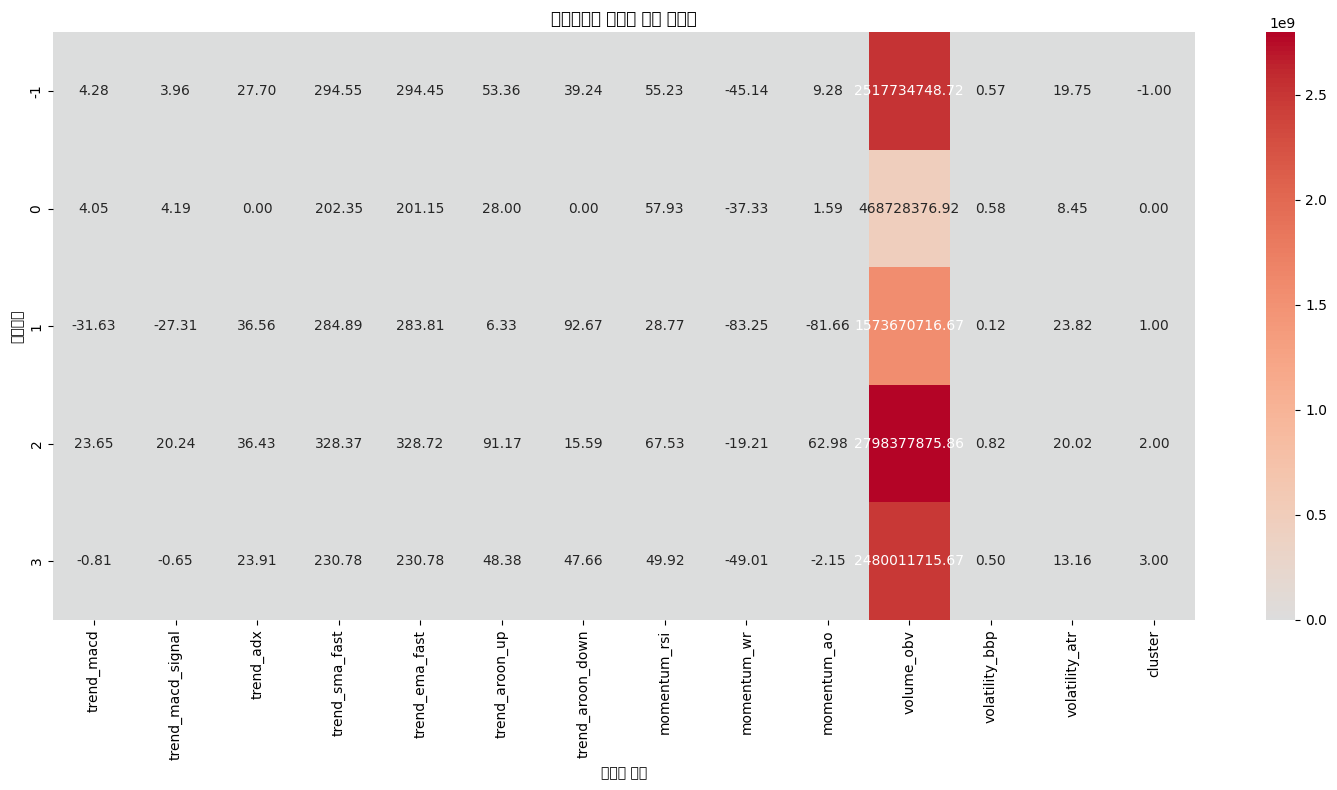

In [202]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 8))
sns.heatmap(cluster_feature_means, cmap='coolwarm', center=0, annot=True, fmt=".2f")
plt.title("클러스터별 기술적 지표 평균값")
plt.xlabel("기술적 지표")
plt.ylabel("클러스터")
plt.tight_layout()
plt.show()


In [203]:
"""
Cluster 0: 수익률이 20일~60일 후까지 지속적으로 양(+)의 방향. 기술적으로는 볼린저밴드 수축 (volatility_bbp 낮음), RSI 낮음 등 과매도 + 저변동성 구간.
Cluster 1: 수익률 90일 기준 **+47%**라는 가장 높은 값. 이건 분명히 상승 전 저점 매집 패턴.
Cluster 2: MACD가 매우 낮고(매우 부정적), RSI도 낮으며, WR은 -82 수준. 즉, 강한 과매도 상태 → 이 또한 반등 시그널.

| Cluster | 주요 특징 요약 (지표 해석)             | 평균 수익률 (90일 기준) | 전략 제안       |
| ------- | ---------------------------- | --------------- | ----------- |
| 0       | 저 RSI, BBP 낮음 (저변동성), AO 하락  | +32.5% (40일)    | 저점 매수 후보    |
| 1       | RSI 57, Aroon down 0 → 상승 준비 | +47.2% (90일)    | 강력한 매집 타이밍  |
| 2       | MACD 매우 낮음, RSI 낮음, WR -82   | +31.5% (60일)    | 반등 초입 예측 가능 |



"""

'\nCluster 0: 수익률이 20일~60일 후까지 지속적으로 양(+)의 방향. 기술적으로는 볼린저밴드 수축 (volatility_bbp 낮음), RSI 낮음 등 과매도 + 저변동성 구간.\nCluster 1: 수익률 90일 기준 **+47%**라는 가장 높은 값. 이건 분명히 상승 전 저점 매집 패턴.\nCluster 2: MACD가 매우 낮고(매우 부정적), RSI도 낮으며, WR은 -82 수준. 즉, 강한 과매도 상태 → 이 또한 반등 시그널.\n\n| Cluster | 주요 특징 요약 (지표 해석)             | 평균 수익률 (90일 기준) | 전략 제안       |\n| ------- | ---------------------------- | --------------- | ----------- |\n| 0       | 저 RSI, BBP 낮음 (저변동성), AO 하락  | +32.5% (40일)    | 저점 매수 후보    |\n| 1       | RSI 57, Aroon down 0 → 상승 준비 | +47.2% (90일)    | 강력한 매집 타이밍  |\n| 2       | MACD 매우 낮음, RSI 낮음, WR -82   | +31.5% (60일)    | 반등 초입 예측 가능 |\n\n\n\n'

In [208]:
# 1. soft clustering probability 추출
cluster_probs = clusterer.probabilities_

# 2. 최소 확률 임계값 설정 (예: 0.85 이상만 사용)
confident_mask = cluster_probs >= 0.85

# 3. 고신뢰 샘플만 선택
X_confident = X_scaled_df.loc[confident_mask].drop(columns='cluster')
y_confident = X_scaled_df.loc[confident_mask, 'cluster']


In [209]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_confident, y_confident, test_size=0.2, random_state=42, stratify=y_confident
)

# 2. 모델 정의 및 학습
model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
model.fit(X_train, y_train)

# 3. 예측
y_pred = model.predict(X_test)

# 4. 평가
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[  2   0   0   0]
 [  0   2   0   0]
 [  0   0   4   0]
 [  0   0   1 140]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2
           2       0.80      1.00      0.89         4
           3       1.00      0.99      1.00       141

    accuracy                           0.99       149
   macro avg       0.95      1.00      0.97       149
weighted avg       0.99      0.99      0.99       149



/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [13:39:58] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [210]:
df_labeled['cluster_pred'] = model.predict(X_scaled_df.drop(columns='cluster'))


In [217]:
df_labeled_pred = df_labeled.copy()
for window in [1, 3, 5, 10, 20, 40, 60, 90]:
    df_labeled_pred[f'return_{window}d'] = df_labeled_pred['Close'].shift(-window) / df_labeled_pred['Close'] - 1

returns_pred = df_labeled_pred.groupby('cluster_pred')[[f'return_{w}d' for w in [1, 3, 5, 10, 20, 40, 60, 90]]].mean()
print(returns_pred)


              return_1d  return_3d  return_5d  return_10d  return_20d  return_40d  return_60d  return_90d
cluster_pred                                                                                             
0              0.005914   0.019388   0.031115    0.050330    0.085735    0.127679    0.192294    0.398975
1             -0.005443  -0.004770  -0.001548    0.008268   -0.011245    0.187720    0.308488         NaN
2              0.000092   0.007654   0.009678    0.029562    0.061597   -0.023659   -0.224646   -0.286868
3              0.001545   0.003554   0.005821    0.011554    0.025833    0.052467    0.074241    0.093912


In [222]:
# 이게 전체 예측 결과
y_pred_full = model.predict(X_scaled_df.drop(columns='cluster'))

# df_final의 index와 정확히 일치함
df_final = df_ta.loc[X_scaled_df.index].copy()
df_final['cluster_pred'] = y_pred_full



In [224]:
# 수익률 컬럼 추가 (df_final에)
for window in [5, 20, 60, 90]:
    df_final[f'return_{window}d'] = df_final['Close'].shift(-window) / df_final['Close'] - 1

# 클러스터 예측값 기준 수익률 계산
returns_pred = df_final.groupby('cluster_pred')[
    [f'return_{w}d' for w in [5, 20, 60, 90]]
].mean().round(4)

print("📊 클러스터별 예측 수익률:")
print(returns_pred)

📊 클러스터별 예측 수익률:
              return_5d  return_20d  return_60d  return_90d
cluster_pred                                               
0                0.0311      0.0857      0.1923      0.3990
1               -0.0015     -0.0112      0.3085         NaN
2                0.0097      0.0616     -0.2246     -0.2869
3                0.0058      0.0258      0.0742      0.0939


In [231]:
# 클러스터 0과 1번을 전략 진입 대상으로 지정
profitable_clusters = [0, 1]

# 진입 신호 업데이트
df_final['entry_signal'] = df_final['cluster_pred'].isin(profitable_clusters).astype(int)

# 진입 시점만 필터링
entry_points = df_final[df_final['entry_signal'] == 1][['Close', 'entry_signal']]
print("📌 진입 신호 발생 시점 (0번, 1번 클러스터 포함):")
print(entry_points)
print(len(entry_points))


📌 진입 신호 발생 시점 (0번, 1번 클러스터 포함):
                 Close  entry_signal
Date                                
2021-05-19  184.183334             1
2021-05-20  191.666672             1
2021-05-21  198.703339             1
2021-05-24  193.866669             1
2021-05-25  202.436661             1
2021-05-26  202.520004             1
2021-05-27  206.746674             1
2021-05-28  209.500000             1
2021-06-01  209.266663             1
2021-06-02  206.710007             1
2021-06-03  200.600006             1
2021-06-04  193.236664             1
2021-06-07  197.276672             1
2021-06-08  207.669998             1
2021-06-09  200.723328             1
2021-06-10  201.293335             1
2021-06-11  203.410004             1
2021-06-14  204.076660             1
2021-06-15  205.563339             1
2021-06-16  199.179993             1
2021-06-17  200.630005             1
2021-06-18  204.456665             1
2021-06-21  208.160004             1
2021-06-22  206.083328             1
2025-0

/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/2264593800.py:13: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/2264593800.py:13: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/2264593800.py:13: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/2264593800.py:13: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel_12963/2264593800.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/57/ff11tjnn7k3d1d5693_01dg00000gn/T/ipykernel

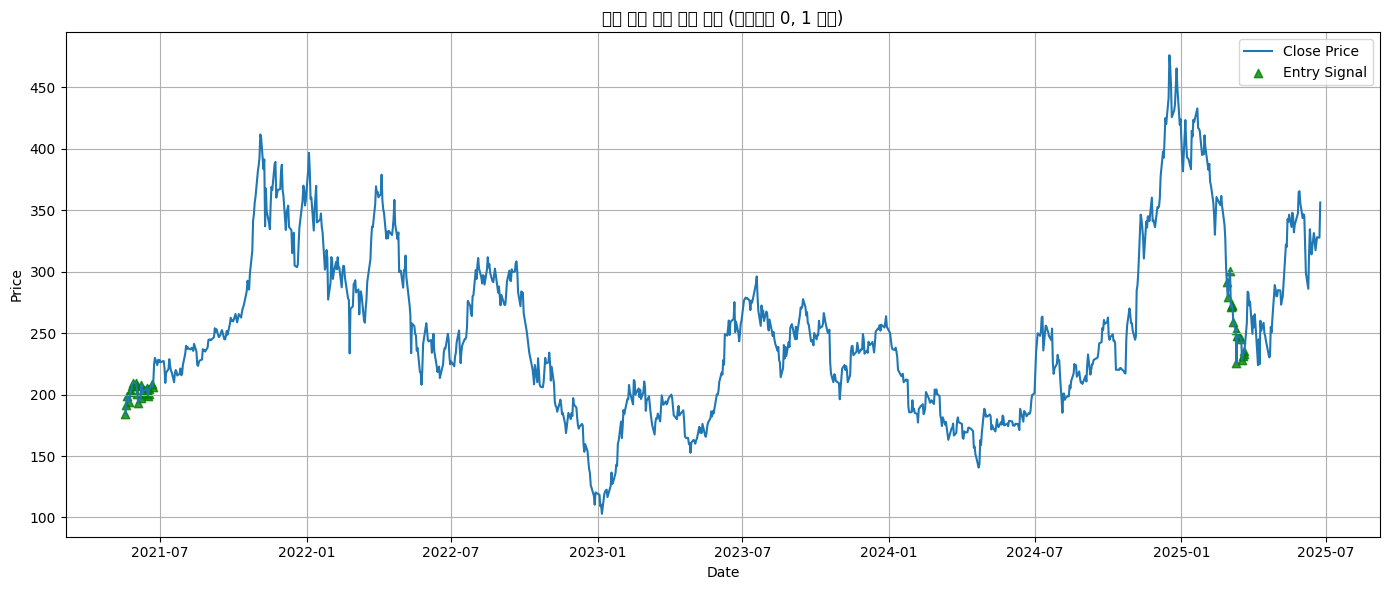

In [227]:
plt.figure(figsize=(14, 6))
plt.plot(df_final['Close'], label='Close Price', linewidth=1.5)

# 진입 시점 표시
entry_dates = df_final[df_final['entry_signal'] == 1].index
plt.scatter(entry_dates, df_final.loc[entry_dates, 'Close'], color='green', marker='^', label='Entry Signal', alpha=0.8)

plt.title('매수 신호 기반 주가 흐름 (클러스터 0, 1 기반)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [228]:
# 진입 후 수익률 확인 (예: 20일 수익률)
entry_return_20d = df_final.loc[df_final['entry_signal'] == 1, 'return_20d']

print(f"📈 진입 후 평균 20일 수익률: {entry_return_20d.mean():.4f}")
print(f"✅ 수익 구간 비율: {(entry_return_20d > 0).mean() * 100:.2f}%")
print(f"📉 손실 구간 비율: {(entry_return_20d < 0).mean() * 100:.2f}%")


📈 진입 후 평균 20일 수익률: 0.0455
✅ 수익 구간 비율: 75.61%
📉 손실 구간 비율: 24.39%


In [ ]:
"""
🔍 [문제 원인 분석]
훈련 데이터에서 상승 구간에 대한 샘플 부족
HDBSCAN은 비지도이기 때문에 상승장이 특정 지표 조합에서 잘 안 잡힐 수 있음.
특히 최근 상승 구간 위주로 클러스터링이 되었다면 과거 상승장이 클러스터에 포함되지 않았을 가능성이 큼.
min_cluster_size=10 설정의 제약
이 값이 작으면 노이즈가 많아지고, 크면 소수 상승 구간을 아예 군집에서 배제할 수 있음.
지표 기반 군집 특성의 과소 표현
MACD, RSI, OBV 등 지표의 기간이 모두 동일하다면, 2021년 상승장과 2025년 상승장의 패턴이 조금만 다르면 같은 클러스터로 분류되지 않을 수 있음.
✅ [개선 방향 제안]
✅ Step 1: 더 다양한 상승 구간을 포착하기 위한 HDBSCAN 재조정

min_cluster_size=5 또는 min_samples=2 등의 값으로 재조정 → 더 민감하게 작동 가능
clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=2)
✅ Step 2: 기술적 지표 세트 다양화

장기 평균선이나 다른 트렌드 지표 추가 추천 (예: trend_sma_slow, trend_ema_slow)
볼린저 밴드 상단/하단 (volatility_bbh, volatility_bbl) 포함
추세 관련 지표의 윈도우 다양화 필요
selected_features += ['trend_sma_slow', 'trend_ema_slow', 'volatility_bbh', 'volatility_bbl']
✅ Step 3: entry_signal 기준 완화

현재는 오직 cluster_pred가 0 또는 1일 때만 진입 시그널 부여
수익률이 높진 않지만 손실이 적고 안정적인 클러스터도 포용하여 백테스트 범위를 확장해볼 수 있음
예:

profitable_clusters = returns_pred[returns_pred['return_20d'] > 0.02].index.tolist()
✅ Step 4: 결과 필터링 시간대 기준 보완

상승장이지만 수익률 계산 기준이 20일 후로 고정돼있으면 매수 시점과 상승 시점이 어긋나는 경우를 포착 못함
return_10d, return_30d, return_60d로 다양화해볼 수 있음.

"""

In [232]:
import joblib
joblib.dump(scaler, '클러스터링 기반 상승 패턴 탐색 scaler.pkl')
joblib.dump(model, '클러스터링 기반 상승 패턴 탐색 xgb_model.pkl')


['클러스터링 기반 상승 패턴 탐색 xgb_model.pkl']

In [237]:
def predict_signal(new_data_df):
    # 저장된 모델과 스케일러 불러오기
    model = joblib.load('클러스터링 기반 상승 패턴 탐색 xgb_model.pkl')
    scaler = joblib.load('클러스터링 기반 상승 패턴 탐색 scaler.pkl')

    # 과거와 동일한 feature list 사용
    feature_cols = [...]  # 과거 X_scaled_df.columns 그대로 지정
    
    # 스케일링
    X_new = scaler.transform(new_data_df[feature_cols])

    # 예측
    cluster_preds = model.predict(X_new)

    # 진입 가능한 클러스터인지 여부 확인
    new_data_df['cluster_pred'] = cluster_preds
    new_data_df['entry_signal'] = new_data_df['cluster_pred'].isin([0, 1]).astype(int)

    return new_data_df[['Close', 'cluster_pred', 'entry_signal']]

In [242]:
# 1. 충분한 기간의 데이터 확보 (예: 최근 120일)
new_data = df[df.index > '2025-01-01'].copy()

# 2. 기술적 지표 계산
new_data_ta = ta.add_all_ta_features(
    new_data,
    open="Open", high="High", low="Low", close="Close", volume="Volume",
    fillna=True
)

# 3. 로그 변환
new_data_ta['volatility_atr'] = np.log1p(new_data_ta['volatility_atr'])

# 4. 우리가 예측하고 싶은 최근 10일만 추출
predict_target = new_data_ta.tail(10).copy()

# 5. 누락된 컬럼 채우기
feature_cols = X_confident.columns.tolist()
missing_cols = list(set(feature_cols) - set(predict_target.columns))
for col in missing_cols:
    predict_target[col] = 0

# 6. 컬럼 순서 정렬
predict_ordered = predict_target[feature_cols]

# 7. 스케일링
X_new_scaled = scaler.transform(predict_ordered)

# 8. 예측
cluster_preds = model.predict(X_new_scaled)

# 9. 진입 시그널 생성
signal = pd.Series(cluster_preds, index=predict_target.index).isin(profitable_clusters).astype(int)

# 10. 결과 저장
result = pd.DataFrame({
    'Close': predict_target['Close'],
    'Predicted Cluster': cluster_preds,
    'Entry Signal': signal
})

print("📌 최근 10일 예측 결과:")
print(result)



📌 최근 10일 예측 결과:
                 Close  Predicted Cluster  Entry Signal
Date                                                   
2025-06-10  314.940002                  0             1
2025-06-11  334.399994                  0             1
2025-06-12  323.079987                  0             1
2025-06-13  313.970001                  3             0
2025-06-16  331.290009                  0             1
2025-06-17  326.089996                  3             0
2025-06-18  317.309998                  3             0
2025-06-20  327.950012                  3             0
2025-06-23  327.540009                  3             0
2025-06-24  356.170013                  0             1


/Users/sung-wonjun/Library/Python/3.9/lib/python/site-packages/ta/trend.py:1030: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  self._psar[i] = high2
